# ArUco Bib Tags & Calibration Strips

Generate, preview, and verify ArUco bib tags with X/Y calibration strips.

**Tag layout**: 9.5 × 13.5 cm (4 per A4 page) with:
- 6 × 6 cm ArUco marker (DICT_4X4_100)
- X calibration strip (bottom, 0–7 cm, 1 cm segments)
- Y calibration strip (left edge, 0–9 cm, 1 cm segments)
- Human-readable bib number

| Section | What |
|---------|------|
| 1 | Generate tags (or load existing) |
| 2 | Individual tag gallery |
| 3 | Print sheets (A4, 4-up with crop marks) |
| 4 | ArUco detection verification |
| 5 | Calibration strip measurement check |
| 6 | Manifest & student assignments |
| 7 | Single tag close-up |

In [10]:
import sys, os, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from IPython.display import display, HTML

# ── Resolve paths ────────────────────────────────────────────────────────────
_cwd = Path(os.path.abspath(''))
PROJ_ROOT = _cwd
for _p in [_cwd, _cwd.parent, _cwd.parent.parent]:
    if (_p / "pipeline").is_dir() and (_p / "configs").is_dir():
        PROJ_ROOT = _p
        break
DATA_ROOT = PROJ_ROOT.parent / "data"
if not DATA_ROOT.is_dir():
    DATA_ROOT = PROJ_ROOT / "data"
sys.path.insert(0, str(PROJ_R
                       OOT))

BIB_TAGS_DIR = DATA_ROOT / "bib_tags"
print(f"Project root:  {PROJ_ROOT}")
print(f"Bib tags dir:  {BIB_TAGS_DIR}  (exists={BIB_TAGS_DIR.is_dir()})")

Project root:  /home/alex/PycharmProjects/vigour-poc/pipeline-poc
Bib tags dir:  /home/alex/PycharmProjects/vigour-poc/data/bib_tags  (exists=True)


## 1. Generate Tags

Generates tags if they don't exist yet. Change `COUNT` / `START_BIB` to regenerate.

In [ ]:
from scripts.generate_bib_tags import (
    generate_all, generate_single_tag, generate_aruco_marker,
    draw_calibration_strip, cm_to_px, ARUCO_DICTS, DPI,
    DEFAULT_MARKER_CM, DEFAULT_TAG_WIDTH_CM, DEFAULT_TAG_HEIGHT_CM,
    STRIP_SEGMENT_CM,
)

# ── Config ───────────────────────────────────────────────────────────────────
COUNT       = 30       # number of bibs
START_BIB   = 1
DICTIONARY  = "DICT_4X4_100"
MARKER_CM   = DEFAULT_MARKER_CM   # 6.0 cm

MANIFEST_PATH = BIB_TAGS_DIR / "manifest.json"

if MANIFEST_PATH.exists():
    with open(MANIFEST_PATH) as f:
        manifest = json.load(f)
    print(f"Loaded existing manifest: {manifest['total_bibs']} bibs, dictionary={manifest['dictionary']}")
else:
    print(f"Generating {COUNT} bib tags...")
    manifest = generate_all(
        count=COUNT,
        start_bib=START_BIB,
        dictionary_name=DICTIONARY,
        marker_cm=MARKER_CM,
        tag_width_cm=DEFAULT_TAG_WIDTH_CM,
        tag_height_cm=DEFAULT_TAG_HEIGHT_CM,
        output_dir=BIB_TAGS_DIR,
    )
    print("Done.")

print(f"\nManifest: {MANIFEST_PATH}")
print(f"  Dictionary:    {manifest['dictionary']}")
print(f"  Marker size:   {manifest['marker_size_cm']} cm")
print(f"  Tag size:      {manifest['tag_size_cm'][0]} x {manifest['tag_size_cm'][1]} cm")
print(f"  Strip segment: {manifest['calibration_strip_segment_cm']} cm")
print(f"  Total bibs:    {manifest['total_bibs']}")
print(f"  Print sheets:  {manifest.get('sheet_count', '?')}")

## 2. Individual Tag Gallery

Each tag: ArUco marker (6 cm) + bib number + X strip (bottom) + Y strip (left), 1 cm segments.

8 tag files found


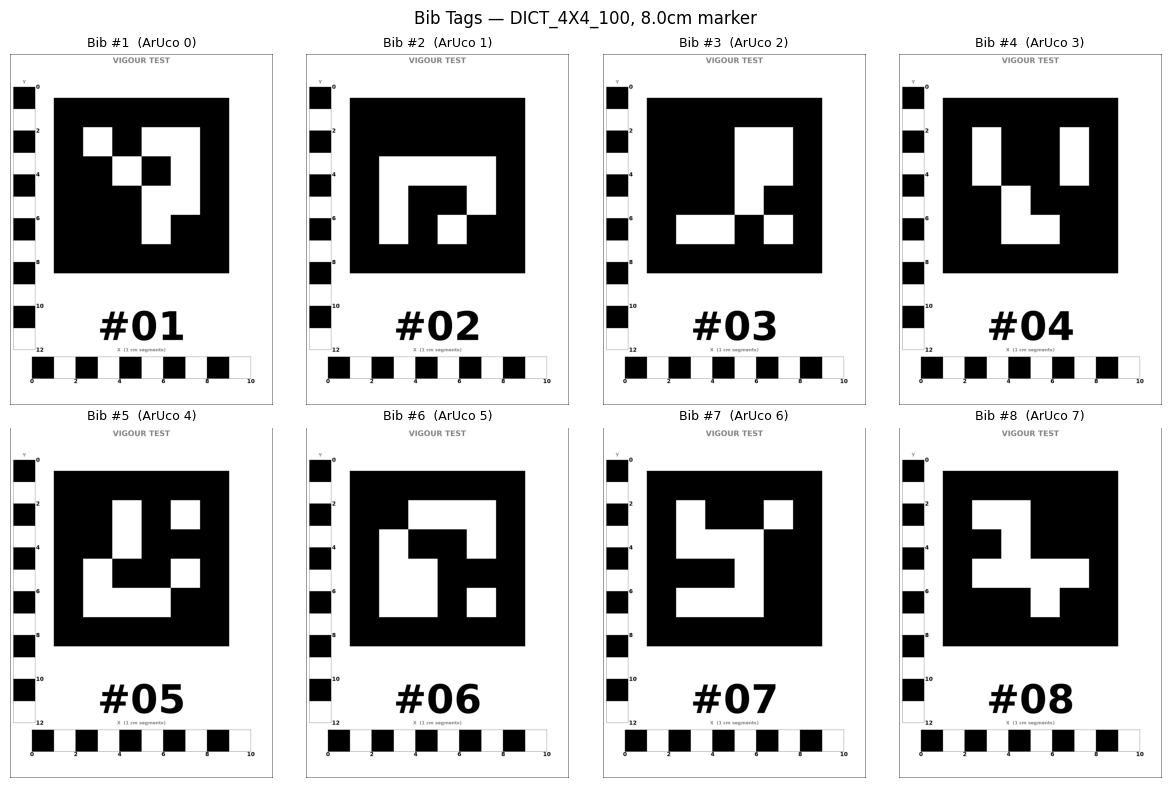

In [12]:
# ── Load individual tag images ───────────────────────────────────────────────
individual_dir = BIB_TAGS_DIR / "individual"
tag_files = sorted(individual_dir.glob("bib_*.png"))
print(f"{len(tag_files)} tag files found")

# Show first N tags in a grid
N_SHOW = min(16, len(tag_files))
cols = 4
rows = (N_SHOW + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 4))
axes = np.array(axes).flatten()

for i in range(N_SHOW):
    img = Image.open(tag_files[i])
    axes[i].imshow(img)
    bib_entry = manifest["bibs"][i]
    axes[i].set_title(f"Bib #{bib_entry['bib_number']}  (ArUco {bib_entry['aruco_id']})", fontsize=9)
    axes[i].axis("off")

# Hide unused axes
for i in range(N_SHOW, len(axes)):
    axes[i].axis("off")

fig.suptitle(f"Bib Tags — {manifest['dictionary']}, {manifest['marker_size_cm']}cm marker", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Print Sheets (A4)

Each sheet has 4 tags in a 2x2 grid with crop marks. Print at **100% scale** (no fit-to-page).

2 print sheets


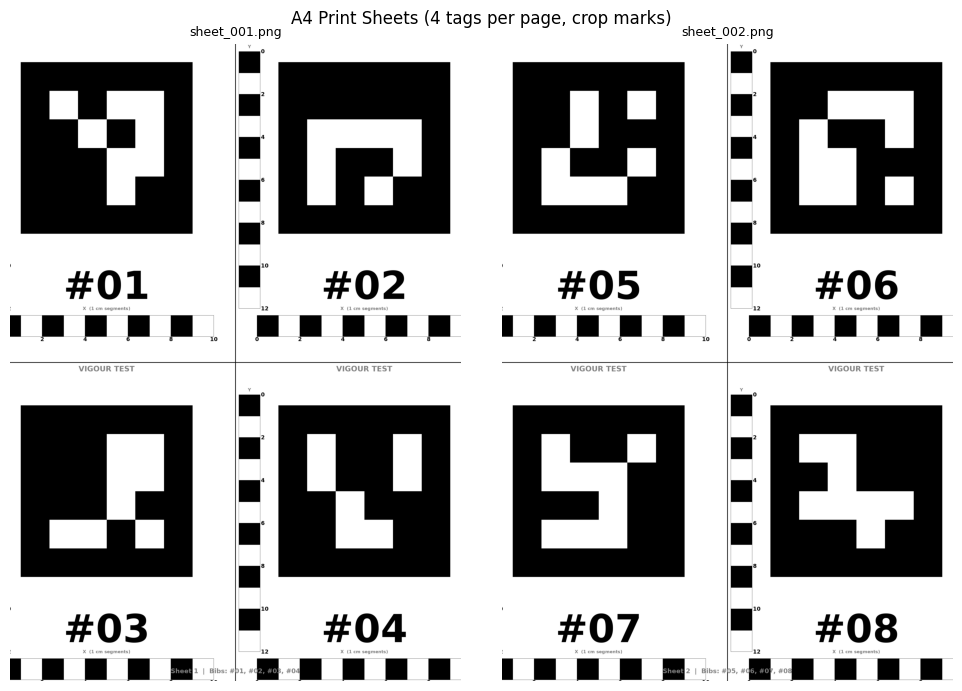

In [13]:
sheets_dir = BIB_TAGS_DIR / "sheets"
sheet_files = sorted(sheets_dir.glob("sheet_*.png"))
print(f"{len(sheet_files)} print sheets")

N_SHEETS = min(4, len(sheet_files))
fig, axes = plt.subplots(1, N_SHEETS, figsize=(N_SHEETS * 5, 7))
if N_SHEETS == 1:
    axes = [axes]

for i, sf in enumerate(sheet_files[:N_SHEETS]):
    img = Image.open(sf)
    axes[i].imshow(img)
    axes[i].set_title(sf.name, fontsize=9)
    axes[i].axis("off")

fig.suptitle("A4 Print Sheets (4 tags per page, crop marks)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. ArUco Detection Verification

Read each tag image back and verify the ArUco marker is detected correctly with the right ID.

Detection: 8/8 markers correctly identified


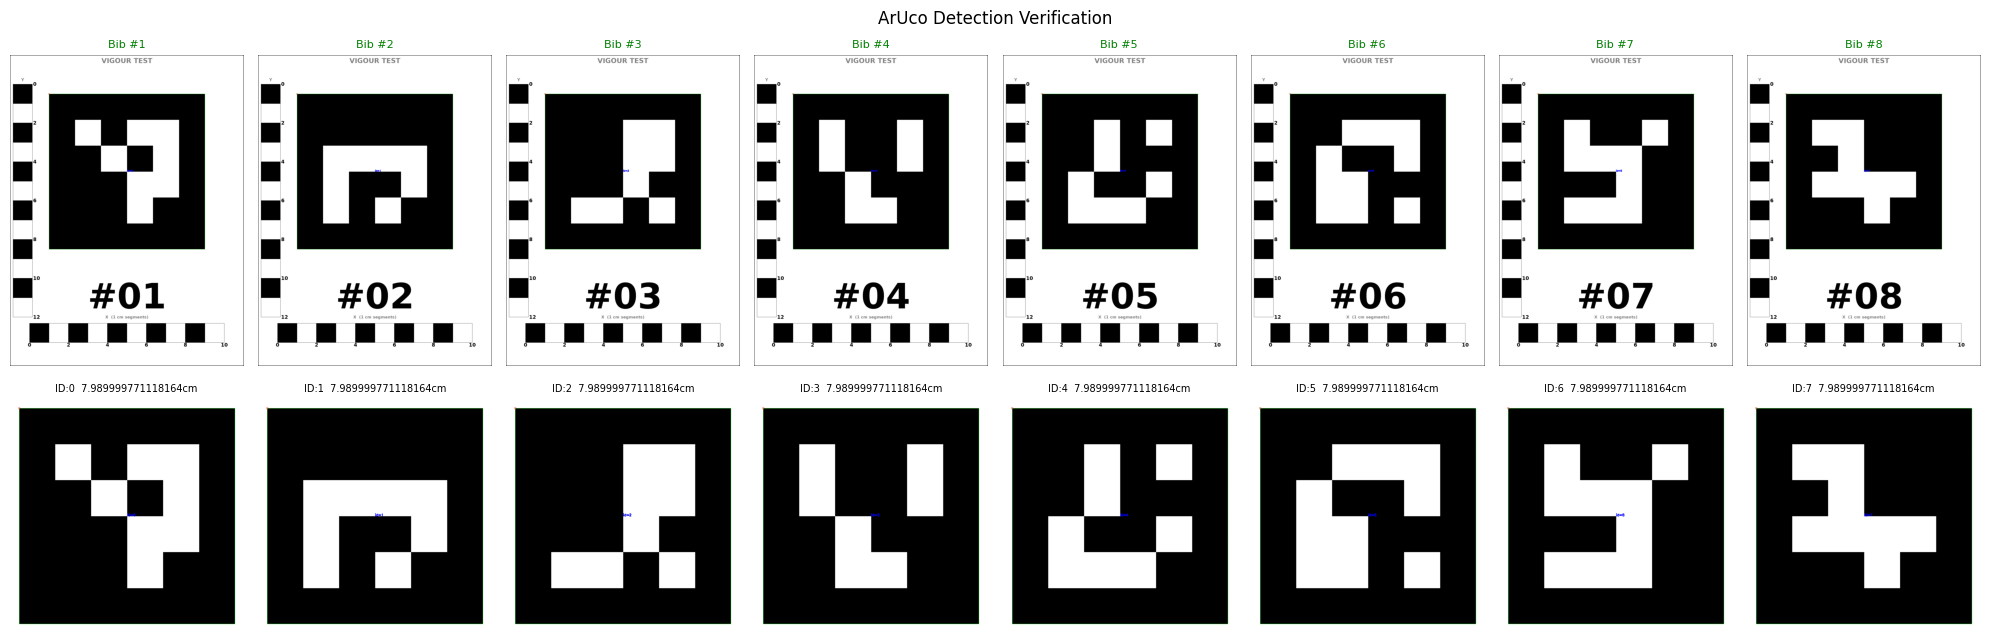

In [14]:
# ── Detect ArUco markers in each tag image ───────────────────────────────────
aruco_dict = cv2.aruco.getPredefinedDictionary(ARUCO_DICTS[manifest["dictionary"]])
detector = cv2.aruco.ArucoDetector(aruco_dict)

detection_results = []
for entry in manifest["bibs"]:
    tag_path = BIB_TAGS_DIR / entry["file"]
    img_bgr = cv2.imread(str(tag_path))
    corners, ids, rejected = detector.detectMarkers(img_bgr)

    detected_id = int(ids[0][0]) if ids is not None and len(ids) > 0 else None
    expected_id = entry["aruco_id"]
    match = detected_id == expected_id

    # Measure marker size in pixels (side length from corners)
    marker_px = None
    if corners is not None and len(corners) > 0:
        c = corners[0][0]  # 4 corner points
        side_lengths = [np.linalg.norm(c[(i+1) % 4] - c[i]) for i in range(4)]
        marker_px = np.mean(side_lengths)

    detection_results.append({
        "bib": entry["bib_number"],
        "expected_id": expected_id,
        "detected_id": detected_id,
        "match": match,
        "marker_px": marker_px,
        "marker_cm_measured": round(marker_px / (DPI / 2.54), 2) if marker_px else None,
    })

# ── Summary ──────────────────────────────────────────────────────────────────
n_ok = sum(1 for r in detection_results if r["match"])
n_total = len(detection_results)
print(f"Detection: {n_ok}/{n_total} markers correctly identified")

if n_ok < n_total:
    print("\nFailed detections:")
    for r in detection_results:
        if not r["match"]:
            print(f"  Bib #{r['bib']}: expected ArUco {r['expected_id']}, got {r['detected_id']}")

# ── Show detection on a few sample tags ──────────────────────────────────────
SAMPLES = min(8, n_total)
fig, axes = plt.subplots(2, SAMPLES, figsize=(SAMPLES * 2.5, 7))

for col in range(SAMPLES):
    entry = manifest["bibs"][col]
    tag_path = BIB_TAGS_DIR / entry["file"]
    img_bgr = cv2.imread(str(tag_path))
    corners, ids, _ = detector.detectMarkers(img_bgr)

    # Draw detected markers
    annotated = img_bgr.copy()
    if ids is not None:
        cv2.aruco.drawDetectedMarkers(annotated, corners, ids)

    # Top row: full tag with detection overlay
    axes[0, col].imshow(annotated[:, :, ::-1])
    r = detection_results[col]
    color = "green" if r["match"] else "red"
    axes[0, col].set_title(f"Bib #{r['bib']}", fontsize=8, color=color)
    axes[0, col].axis("off")

    # Bottom row: zoomed ArUco marker region
    if corners is not None and len(corners) > 0:
        c = corners[0][0]
        x_min, y_min = c.min(axis=0).astype(int)
        x_max, y_max = c.max(axis=0).astype(int)
        pad = 40
        crop = annotated[max(0, y_min-pad):y_max+pad, max(0, x_min-pad):x_max+pad]
        axes[1, col].imshow(crop[:, :, ::-1])
        axes[1, col].set_title(f"ID:{r['detected_id']}  {r['marker_cm_measured']}cm", fontsize=7)
    else:
        axes[1, col].text(0.5, 0.5, "NOT\nDETECTED", ha="center", va="center", color="red", fontsize=10,
                          transform=axes[1, col].transAxes)
    axes[1, col].axis("off")

fig.suptitle("ArUco Detection Verification", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Calibration Strip Measurement

Verify the calibration strip produces the correct px/cm ratio at 300 DPI. Expected: `marker_size_px / marker_cm = DPI / 2.54`.

Expected px/cm at 300 DPI:  118.11
Expected marker side:          945 px  (8.0 cm)

Measured marker side:          944.0 +/- 0.00 px
Measured marker size:          7.990 cm  (expected 8.0 cm)
Measurement error:             0.0100 cm  (0.13%)
Derived px/cm:                 118.00


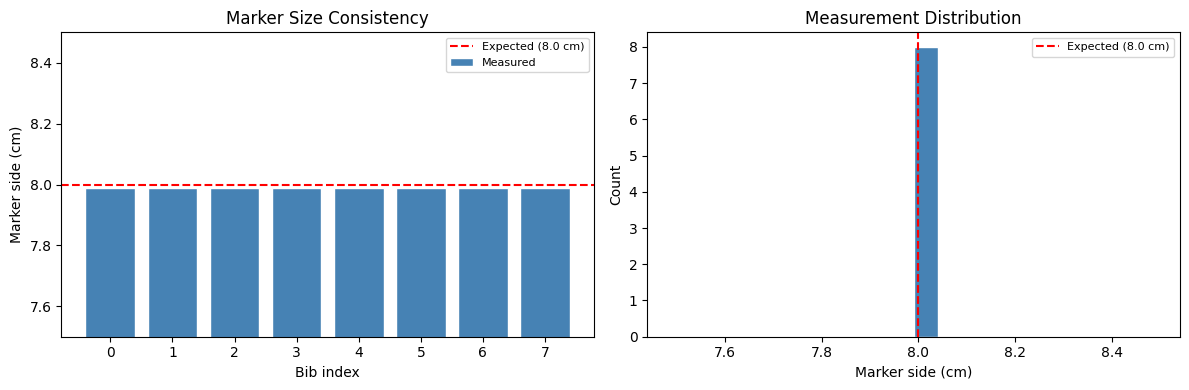

In [15]:
# ── Calibration accuracy from ArUco marker corners ──────────────────────────
expected_px_per_cm = DPI / 2.54
marker_cm = manifest["marker_size_cm"]

measured_px = [r["marker_px"] for r in detection_results if r["marker_px"] is not None]
measured_cm = [r["marker_cm_measured"] for r in detection_results if r["marker_cm_measured"] is not None]

print(f"Expected px/cm at {DPI} DPI:  {expected_px_per_cm:.2f}")
print(f"Expected marker side:          {cm_to_px(marker_cm)} px  ({marker_cm} cm)")
print()

if measured_px:
    mean_px = np.mean(measured_px)
    std_px = np.std(measured_px)
    mean_cm = np.mean(measured_cm)
    error_cm = abs(mean_cm - marker_cm)

    print(f"Measured marker side:          {mean_px:.1f} +/- {std_px:.2f} px")
    print(f"Measured marker size:          {mean_cm:.3f} cm  (expected {marker_cm} cm)")
    print(f"Measurement error:             {error_cm:.4f} cm  ({error_cm/marker_cm*100:.2f}%)")
    print(f"Derived px/cm:                 {mean_px / marker_cm:.2f}")

    # ── Scatter plot: measured vs expected ────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    bibs = [r["bib"] for r in detection_results if r["marker_px"] is not None]
    ax1.bar(range(len(measured_cm)), measured_cm, color="steelblue", edgecolor="white", label="Measured")
    ax1.axhline(y=marker_cm, color="red", linestyle="--", linewidth=1.5, label=f"Expected ({marker_cm} cm)")
    ax1.set_xlabel("Bib index")
    ax1.set_ylabel("Marker side (cm)")
    ax1.set_title("Marker Size Consistency")
    ax1.legend(fontsize=8)
    ax1.set_ylim(marker_cm - 0.5, marker_cm + 0.5)

    # Histogram of measured sizes
    ax2.hist(measured_cm, bins=20, color="steelblue", edgecolor="white")
    ax2.axvline(x=marker_cm, color="red", linestyle="--", linewidth=1.5, label=f"Expected ({marker_cm} cm)")
    ax2.set_xlabel("Marker side (cm)")
    ax2.set_ylabel("Count")
    ax2.set_title("Measurement Distribution")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("No markers detected — cannot verify calibration.")

## 6. Manifest & Student Assignments

View the bib-to-ArUco mapping and assign students.

In [16]:
import pandas as pd

rows = []
for entry in manifest["bibs"]:
    r = next((d for d in detection_results if d["bib"] == entry["bib_number"]), {})
    rows.append({
        "Bib #": entry["bib_number"],
        "ArUco ID": entry["aruco_id"],
        "Student": entry.get("student_name") or "",
        "Assigned": (entry.get("assigned_date") or "")[:10],
        "Detected": "Y" if r.get("match") else "N",
        "Marker (cm)": r.get("marker_cm_measured", ""),
    })

df = pd.DataFrame(rows)
display(HTML(f"<h3>Bib Manifest — {len(rows)} tags</h3>"))
display(HTML(df.to_html(index=False)))

Bib #,ArUco ID,Student,Assigned,Detected,Marker (cm)
1,0,,,Y,7.99
2,1,,,Y,7.99
3,2,,,Y,7.99
4,3,,,Y,7.99
5,4,,,Y,7.99
6,5,,,Y,7.99
7,6,,,Y,7.99
8,7,,,Y,7.99


### Assign students (edit and re-run)

Uncomment and modify the assignments dict below, then re-run to update the manifest.

In [17]:
from scripts.generate_bib_tags import assign_student

# ── Uncomment and edit to assign students ────────────────────────────────────
# assign_student(MANIFEST_PATH, bib_number=1, student_name="Liam van der Berg")
# assign_student(MANIFEST_PATH, bib_number=2, student_name="Thando Nkosi")
# assign_student(MANIFEST_PATH, bib_number=3, student_name="Aisha Patel")

# ── Or bulk-assign from CSV ──────────────────────────────────────────────────
# from scripts.generate_bib_tags import assign_bulk
# assign_bulk(MANIFEST_PATH, Path("roster.csv"))  # CSV: bib_number,student_name

print("Edit the assignments above and re-run this cell to update the manifest.")

Edit the assignments above and re-run this cell to update the manifest.


## 7. Single Tag Close-up

Detailed view of one tag with annotated regions.

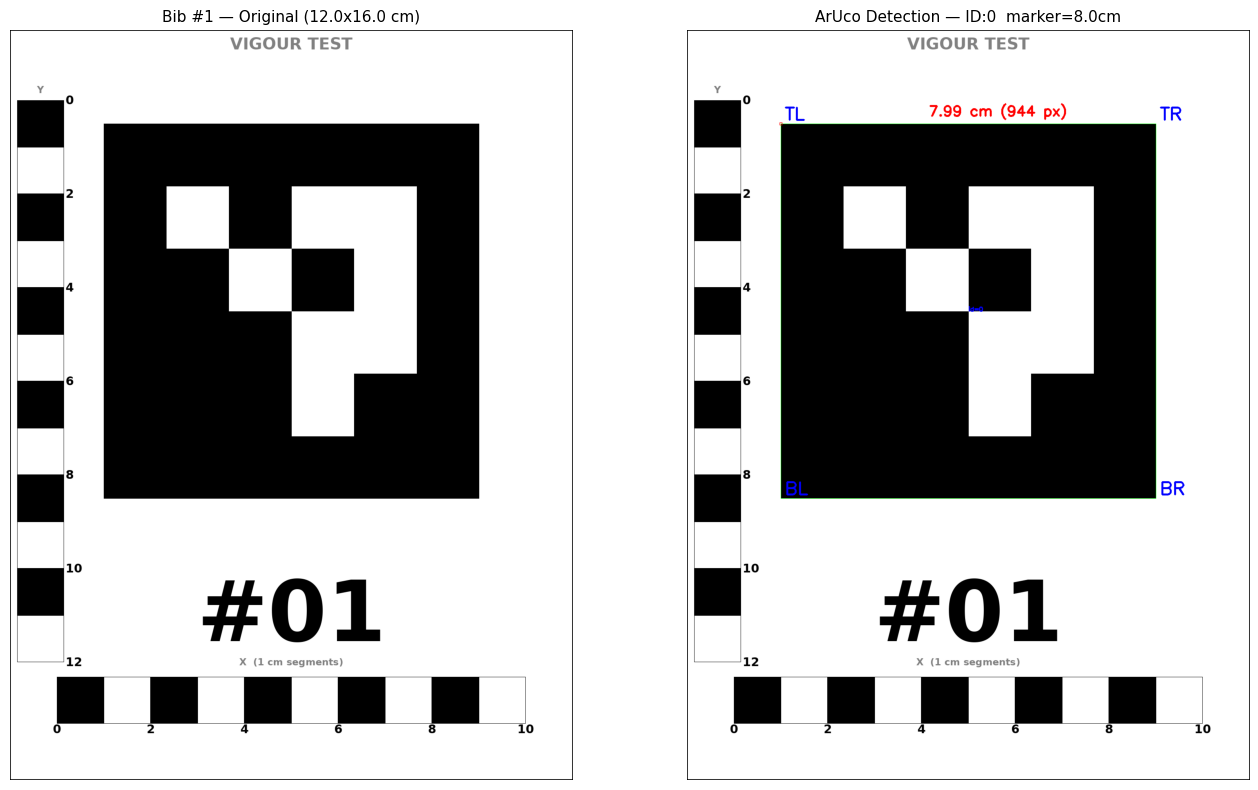

Bib #1
  ArUco ID:       0 (detected: 0)
  Match:          YES
  Marker px:      944.0 px
  Marker cm:      7.989999771118164 cm (expected 8.0 cm)
  px/cm:          118.00 (expected 118.11)
  Student:        (unassigned)


In [18]:
# ── Close-up of a single tag with detection overlay and annotations ──────────
BIB_TO_SHOW = 1  # change this to inspect a different bib

entry = next(e for e in manifest["bibs"] if e["bib_number"] == BIB_TO_SHOW)
tag_path = BIB_TAGS_DIR / entry["file"]
img_bgr = cv2.imread(str(tag_path))
corners, ids, rejected = detector.detectMarkers(img_bgr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Left: original tag
ax1.imshow(Image.open(tag_path))
ax1.set_title(f"Bib #{BIB_TO_SHOW} — Original ({manifest['tag_size_cm'][0]}x{manifest['tag_size_cm'][1]} cm)", fontsize=11)
ax1.axis("off")

# Right: detection overlay with corner markers
annotated = img_bgr.copy()
if ids is not None:
    cv2.aruco.drawDetectedMarkers(annotated, corners, ids)
    c = corners[0][0]
    # Draw corner labels
    for ci, label in enumerate(["TL", "TR", "BR", "BL"]):
        px, py = int(c[ci][0]), int(c[ci][1])
        cv2.putText(annotated, label, (px+10, py-10), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 0, 0), 3)
    # Draw measured side length
    side_px = np.linalg.norm(c[1] - c[0])
    side_cm = side_px / (DPI / 2.54)
    mid_x = int((c[0][0] + c[1][0]) / 2)
    mid_y = int((c[0][1] + c[1][1]) / 2) - 20
    cv2.putText(annotated, f"{side_cm:.2f} cm ({int(side_px)} px)",
                (mid_x - 100, mid_y), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

ax2.imshow(annotated[:, :, ::-1])
ax2.set_title(f"ArUco Detection — ID:{entry['aruco_id']}  marker={manifest['marker_size_cm']}cm", fontsize=11)
ax2.axis("off")

plt.tight_layout()
plt.show()

# Print details
r = next(d for d in detection_results if d["bib"] == BIB_TO_SHOW)
print(f"Bib #{BIB_TO_SHOW}")
print(f"  ArUco ID:       {r['expected_id']} (detected: {r['detected_id']})")
print(f"  Match:          {'YES' if r['match'] else 'NO'}")
print(f"  Marker px:      {r['marker_px']:.1f} px")
print(f"  Marker cm:      {r['marker_cm_measured']} cm (expected {marker_cm} cm)")
print(f"  px/cm:          {r['marker_px']/marker_cm:.2f} (expected {expected_px_per_cm:.2f})")
print(f"  Student:        {entry.get('student_name') or '(unassigned)'}")